# 2020 SQM Data Plotter
**Basic functionality:**
<ul>
    <li> Read data using sqm_read2020 and ars_read2020. </li>
    <li> Clean data – float & lists create issues! </li>
    <li> Filter the data by lunar phase, cloud cover, and particulate matter </li>
</ul>

In [3]:
import sqm_read2020
# import sqm_plot2020
import ars_read2020
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

fname = '/Users/jacksontobin/Local_Documents/NightTime_Research/FoCo Night Sky Team/Fort Collins SQM Monitoring 2020/Fort Collins SQM 2020 data(all_sites_copy2).csv'

## Step 1: Read the Data

In [4]:

# Read the data without filtering the lunar phase or cloud cover
dataframes = sqm_read2020.read_2020(fname=fname, filter_phase=False, filter_cloud=False)

# Read the ARS data 
date_arr = dataframes[0].index
# Riverbend, soapstone, fossil creek, fcmod.
df_ben, df_sop, df_fos, df_dis = ars_read2020.ars_read2020(date_arr=date_arr)

# Now we can plot the data by filtering out each lunar phase and cloud cover
# Let's just look at one location:
# 0: FRNA (HZ), 1: FRNA (ZN), 2: FCMOD, 3: PFA1, 4: PFA2, 5: HILT, 6: SPZN, 7: SPHZ
loc = 6
df_fcmod = dataframes[loc]

## Step 2) Clean the Data

In [5]:

# Clean up the lunar_alt column: some rows are lists, some are floats!?
df_fcmod['lunar_alt'] = df_fcmod['lunar_alt'].apply(
    lambda x: x[0] if isinstance(x, list) else x)
df_fcmod['lunarphaseclass'] = df_fcmod['lunarphaseclass'].apply(
    lambda x: x[0] if isinstance(x, list) else x)
df_fcmod['mags'] = df_fcmod['mags'].apply(
    lambda x: x[0] if isinstance(x, list) else x)
df_fcmod['CC'] = df_fcmod['CC'].apply(
    lambda x: x[0] if isinstance(x, list) else x)


## Step 3) Plot the Data

Create a plot of the SQM / ARS data

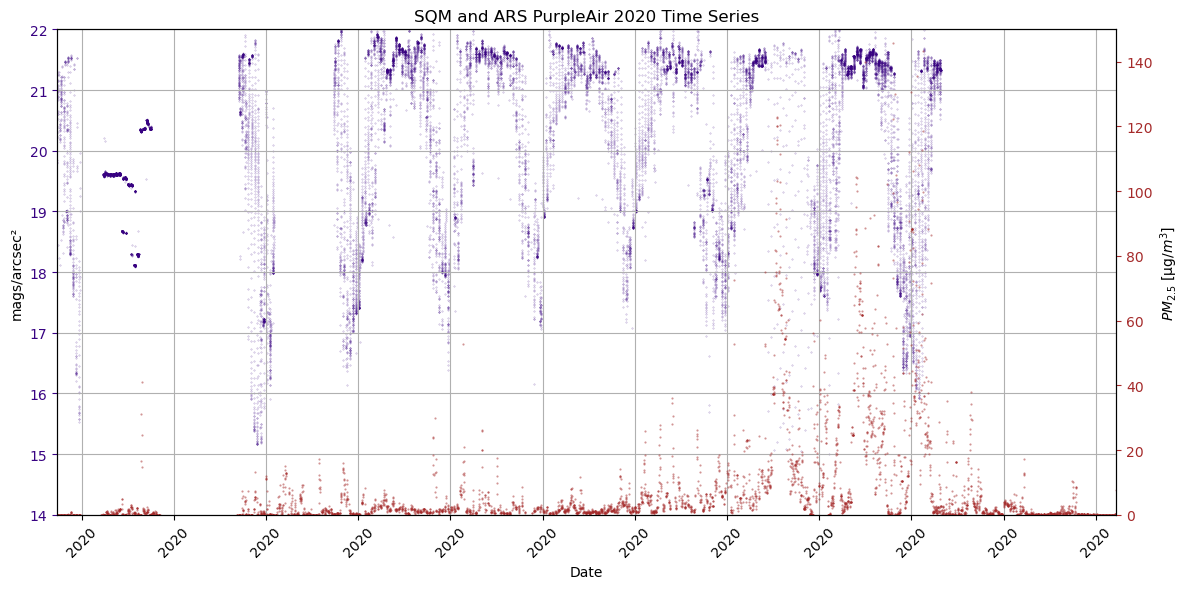

In [6]:
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(12,6))

sc1_color = '#380282'
ax.scatter(df_fcmod.index, df_fcmod['mags'], s=0.3, c=sc1_color, alpha=0.45, marker='.', label='SQM')
ax.set_xlim(df_fcmod.index.min(), df_fcmod.index.max()) # From Jan 01 to Dec 31
ax.xaxis.set_major_locator(plt.MaxNLocator(13)) # 13 = 12 months
ax.tick_params(axis='x', rotation=45)
ax.set_ylabel('mags/arcsec²')
ax.tick_params('y',colors=sc1_color)
ax.grid()
ax.set_ylim(14, 22) # data truncated at these values
ax.set_xlabel("Date")

sc2_color = '#A52A2A'
ax2 = ax.twinx()
ax2.scatter(df_sop.index, df_sop['AQI'], s=0.3, c=sc2_color, alpha=0.5, marker='x',label='ARS')
ax2.set_ylim(0, 150)
ax2.tick_params('y',colors=sc2_color)
ytitle = r'$PM_{2.5}$ [µg/$m^3$]'
ax2.set_ylabel(ytitle)

ax.set_title('SQM and ARS PurpleAir 2020 Time Series')

plt.tight_layout()
plt.show()


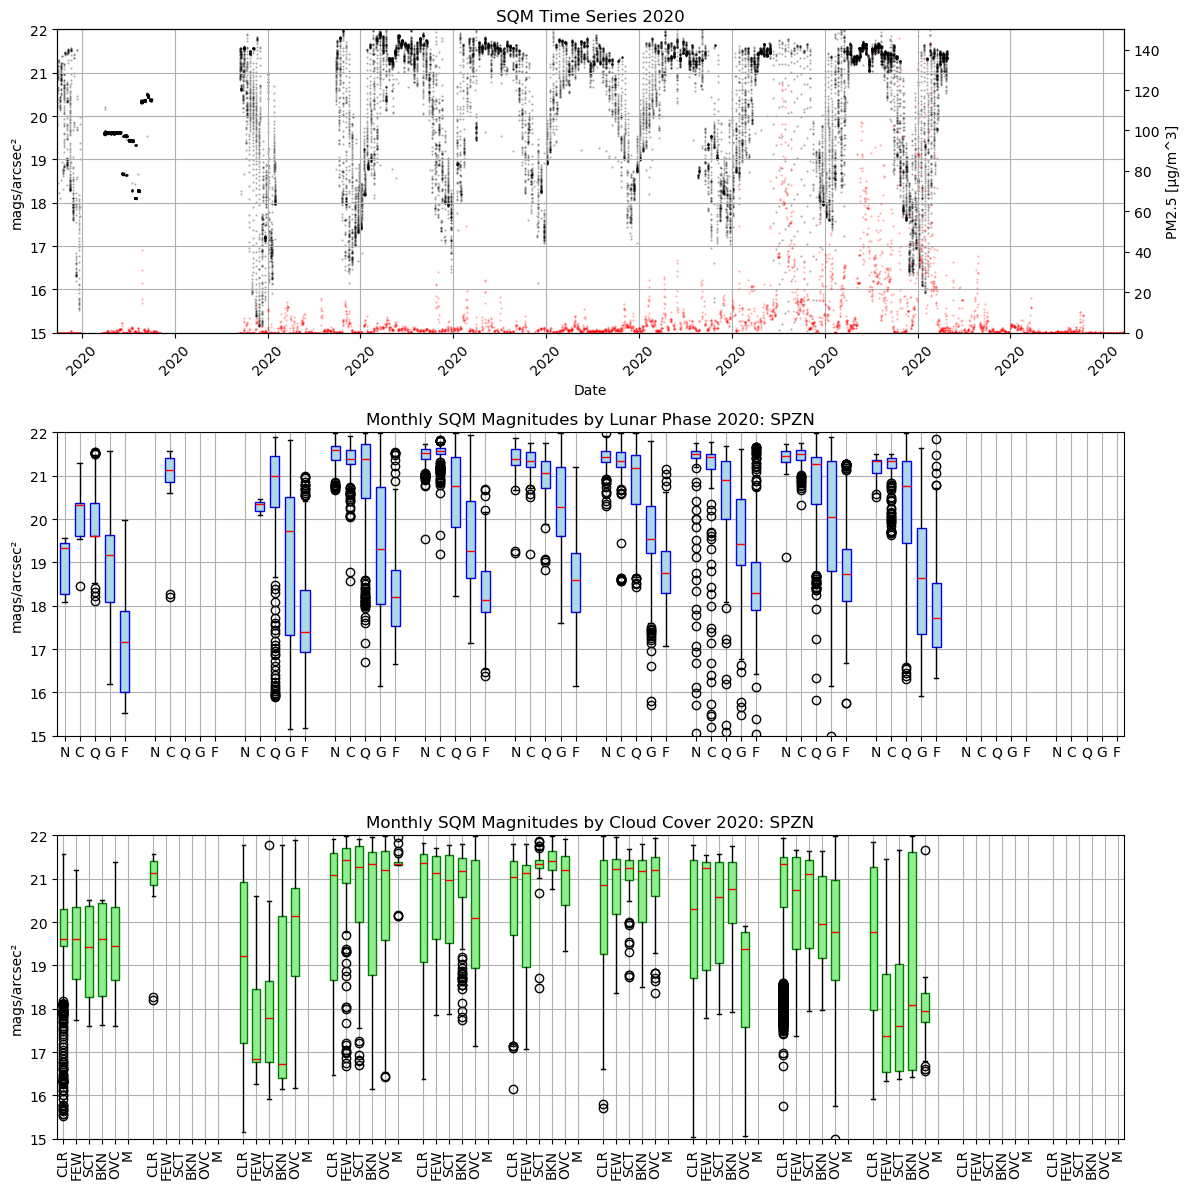

In [ ]:
import sqm_plot2020

# Define the cloud cover that you want to filter out:
# coverages = ['OVC', 'SCT', 'FEW', 'BKN', 'M']
# df_fcmod = sqm_read2020.filter_sqm_cloud(df_fcmod, coverage=coverages)

# Define the lunar phases and altitudes to filter out:
# phases = ['Full', 'Gibbous', 'Crescent', 'Quarter']
# alts = [-5, -5, -5, -5]
# df_fcmod = sqm_read2020.filter_sqm_lunar(df_fcmod, lunar_phase=phases, lunar_alt=alts)

# Now let's plot!
sqm_plot2020.sqm_plotx2020(df_fcmod, ars_dataframe=df_sop, plot_ars=True)

## Next step: 
Investigate a correlation between SQM clear, moonless skies and ARS PM2.5 for 2020.

In [8]:

# # # Filter out these lunar phases:
phases = ['Full', 'Gibbous', 'Crescent', 'Quarter']
alts = [-5, -5, -5, -5]
df_fcmod = sqm_read2020.filter_sqm_lunar(df_fcmod, lunar_phase=phases, lunar_alt=alts)

# # Filter out cloud coverage
coverages = ['OVC', 'SCT', 'FEW', 'BKN', 'M']
df_fcmod = sqm_read2020.filter_sqm_cloud(df_fcmod, coverage=coverages)

Plot ARS against the filtered SQM

Text(0.5, 0, 'AQI')

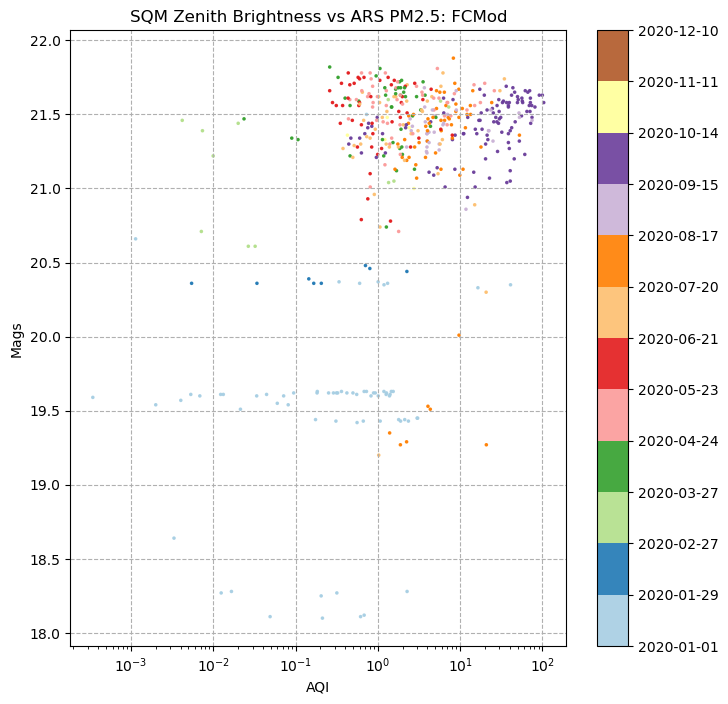

In [9]:
# Convert the index to numeric values for colormapping
dates_numeric = pd.to_datetime(df_fcmod.index).astype(np.int64)
colors = dates_numeric

# Normalize to [0, 1] for the colormap
norm = mcolors.Normalize(vmin=dates_numeric.min(), vmax=dates_numeric.max())
cmap = cm.Paired  # or try: plasma, inferno, coolwarm, turbo

fig = plt.figure(figsize=(8,8))
ax  = plt.axes()
sct = ax.scatter(df_sop['AQI'], df_fcmod['mags'], marker='.', s=10, c=colors, cmap=cmap, norm=norm, alpha=0.9)
cbar = fig.colorbar(sct, ax=ax)
tick_vals = np.linspace(dates_numeric.min(), dates_numeric.max(), 13)
tick_dates = pd.to_datetime(tick_vals).strftime('%Y-%m-%d')
cbar.set_ticks(tick_vals)
cbar.set_ticklabels(tick_dates)
ax.grid(True, linestyle='--')
ax.set_xscale('log')
# ax.set_ylim(21, 22)
# ax.set_xlim(0, 85)
ax.set_title('SQM Zenith Brightness vs ARS PM2.5: FCMod')
ax.set_ylabel('Mags')
ax.set_xlabel('AQI')